In [1]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/lotanamit/WhatDoLLMsWant


# Drop Apple entirely — what survives?

Every brand result so far has been dominated by one brand. This repeats the main measurements on
the subset of comparisons where **neither laptop is an Apple**, across all three families.

Dropping every pair containing an Apple leaves **36 laptops (4 brands x 3 x 3)** and
**6300 of the 9900 rows**. The fit then has four brand levels instead of five.

Three questions:

| # | question | why it matters |
|---|---|---|
| 1 | does **adherence** change? | κ is about screen/ram. If it moves when Apple leaves, something is wrong with the measurement. |
| 2 | does **base vs aligned** agreement change? | tests whether "preferences are pretrained" rests on Apple. |
| 3 | does the **brand decay** survive? | the real question — is there a contract effect on brands *at all* without Apple? |

Method unchanged; notation in [explainer_metrics.ipynb](explainer_metrics.ipynb).

In [2]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

from src.bt import FeatureBT

SAVE = True
FIGDIR = "figs/no_apple"
os.makedirs(FIGDIR, exist_ok=True)

BRANDS = ["ASUS", "Apple", "Dell", "HP", "Lenovo"]
OTHER4 = [b for b in BRANDS if b != "Apple"]
SCREEN, RAM = ["13-inch", "14-inch", "16-inch"], ["4GB", "8GB", "16GB"]
LEVELS = {"brand": BRANDS, "screen": SCREEN, "ram": RAM}
LEVELS4 = {"brand": OTHER4, "screen": SCREEN, "ram": RAM}
CON = ["none", "screen=14-inch", "ram=8GB", "ram=8GB+screen=14-inch"]
CLAB = dict(zip(CON, ["none", "14in", "8GB", "14in+8GB"]))
cols = [CLAB[c] for c in CON]
EXPECT, FRAME = 9900, "shopping"

ALIGNED = ([("qwen", s) for s in ["7", "32", "72"]]
           + [("gemma", s) for s in ["1", "4", "12", "27"]]
           + [("olmo", s) for s in ["1", "7", "13", "32"]])
PAIRS = ([("qwen-pt", "qwen", s) for s in ["7", "32", "72"]]
         + [("olmo-pt", "olmo", s) for s in ["1", "7", "13"]])

BRAND_COLOR = dict(zip(BRANDS, ["#2a78d6", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]))
BRAND_MARKER = dict(zip(BRANDS, ["o", "s", "^", "D", "v"]))
FAM_COLOR = {"qwen": "#2a78d6", "gemma": "#eb6834", "olmo": "#1baf7a"}
INCL_C, EXCL_C = "#eda100", "#52514e"
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#d6d5d1",
    "axes.labelcolor": INK, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED, "axes.grid": True,
    "grid.color": "#e8e7e3", "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "figure.dpi": 110, "font.size": 10,
    "savefig.bbox": "tight", "savefig.dpi": 200,
})
pd.set_option("display.width", 240)

def save(fig, name):
    if SAVE:
        fig.savefig(os.path.join(FIGDIR, name + ".png"), facecolor=SURFACE)
    return fig


def load(bases, frame=FRAME, cons=CON, expect=EXPECT):
    """Complete runs only - config.json without scores.csv is a dead job."""
    R = {}
    for base in bases:
        if not os.path.isdir(base):
            continue
        for run in sorted(os.listdir(base)):
            p = os.path.join(base, run)
            cf, sc = os.path.join(p, "config.json"), os.path.join(p, "scores.csv")
            if not (os.path.isfile(cf) and os.path.isfile(sc)):
                continue
            c = json.load(open(cf))
            if c["frame"]["name"] != frame or c["constraints_id"] not in cons:
                continue
            d = pd.read_csv(sc)
            if len(d) != expect:
                continue
            key = (c["model_family"], str(c["model_size"]), c["constraints_id"])
            assert key not in R, f"two complete runs share {key}"
            R[key] = d
    return R


def drop_apple(d):
    """Keep only comparisons where NEITHER laptop is an Apple."""
    return d[(d.a_brand != "Apple") & (d.b_brand != "Apple")].reset_index(drop=True)


RUNS = load(["data/laptops_olmo", "data/laptops_olmo_pt", "data/laptops_robustness",
             "data/laptops_robustness_gemma", "data/laptops_robustness_pt"])
ex = RUNS[("qwen", "7", "none")]
print(f"{len(RUNS)} complete runs loaded")
print(f"rows per run: {len(ex)} -> {len(drop_apple(ex))} after dropping Apple pairs")
print(f"brands in the fit: {len(BRANDS)} -> {len(OTHER4)}")

def fit_both(d):
    """(fit on everything, fit with Apple pairs removed)."""
    return FeatureBT(r2_warn=None).fit(d), FeatureBT(r2_warn=None).fit(drop_apple(d))

94 complete runs loaded
rows per run: 9900 -> 6300 after dropping Apple pairs
brands in the fit: 5 -> 4


---
# Q1 — adherence

κ and the conflict win rate are about **screen and ram**. Removing Apple should barely touch
them: it only removes brand-tied pairs, dropping each cell from 75 unordered pairs to 60. If
these numbers moved, the adherence measurement would be entangled with brand, which it should
not be.

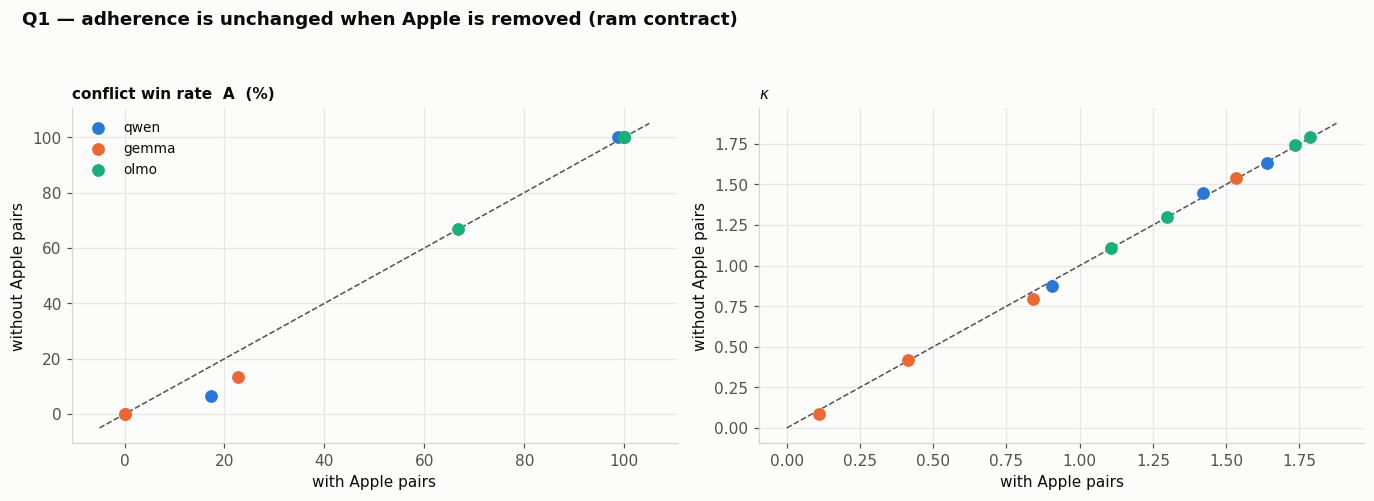

    model  n_incl  n_excl  A_incl  A_excl  k_incl  k_excl
  qwen-7B      75      60   98.67  100.00    1.42    1.45
 qwen-32B      75      60   17.33    6.67    0.91    0.88
 qwen-72B      75      60  100.00  100.00    1.64    1.63
 gemma-1B      75      60    0.00    0.00    0.11    0.09
 gemma-4B      75      60    0.00    0.00    0.41    0.42
gemma-12B      75      60   22.67   13.33    0.84    0.80
gemma-27B      75      60  100.00  100.00    1.53    1.54
  olmo-1B      75      60   66.67   66.67    1.11    1.11
  olmo-7B      75      60  100.00  100.00    1.73    1.74
 olmo-13B      75      60  100.00  100.00    1.30    1.30
 olmo-32B      75      60  100.00  100.00    1.79    1.79

largest change in kappa: 0.045
mean |change| in kappa:  0.015


In [3]:
def paired_D(d, feat, u, v):
    m = (d.score_a - d.score_b).values
    tie = np.ones(len(d), bool)
    for o in [x for x in ("brand", "screen", "ram") if x != feat]:
        tie &= (d[f"a_{o}"] == d[f"b_{o}"]).values
    pair = (((d[f"a_{feat}"] == u) & (d[f"b_{feat}"] == v))
            | ((d[f"a_{feat}"] == v) & (d[f"b_{feat}"] == u))).values
    is_u = (d[f"a_{feat}"] == u).values
    key = np.char.add(np.char.add(d.a_brand.values, "|"),
          np.char.add(np.where(d.a_screen.values == d.b_screen.values, d.a_screen.values, "x"),
          np.char.add(np.where(d.a_ram.values == d.b_ram.values, d.a_ram.values, "x"),
                      d.template_idx.astype(str).values)))
    t = pd.DataFrame({"k": key, "v": np.where(is_u, m, -m)})[tie & pair]
    g = t.groupby("k")["v"].agg(["mean", "size"])
    return g[g["size"] == 2]["mean"].values


ASKED = {"screen": "14-inch", "ram": "8GB"}
RIVAL = {"screen": "16-inch", "ram": "16GB"}
RUN_OF = {"screen": "screen=14-inch", "ram": "ram=8GB"}

rows = []
for fam, s in ALIGNED:
    for feat in ("ram", "screen"):
        k1, k0 = (fam, s, RUN_OF[feat]), (fam, s, "none")
        if k1 not in RUNS or k0 not in RUNS:
            continue
        rec = dict(model=f"{fam}-{s}B", fam=fam, feat=feat)
        for tag, f in [("incl", lambda x: x), ("excl", drop_apple)]:
            D1 = paired_D(f(RUNS[k1]), feat, ASKED[feat], RIVAL[feat])
            D0 = paired_D(f(RUNS[k0]), feat, ASKED[feat], RIVAL[feat])
            rec[f"n_{tag}"] = len(D1)
            rec[f"A_{tag}"] = 100 * (D1 > 0).mean()
            rec[f"k_{tag}"] = 1 - D1.mean() / D0.mean()
        rows.append(rec)
ADH = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))
for ax, (c_in, c_ex, lab) in zip(axes, [("A_incl", "A_excl", "conflict win rate  A  (%)"),
                                        ("k_incl", "k_excl", r"$\kappa$")]):
    sub = ADH[ADH.feat == "ram"]
    lim = [min(sub[c_in].min(), sub[c_ex].min()), max(sub[c_in].max(), sub[c_ex].max())]
    pad = .05 * (lim[1] - lim[0] + 1e-9)
    ax.plot([lim[0] - pad, lim[1] + pad], [lim[0] - pad, lim[1] + pad], ls="--", lw=1,
            color=INK_MUTED, zorder=1)
    for fam in ["qwen", "gemma", "olmo"]:
        t = sub[sub.fam == fam]
        ax.scatter(t[c_in], t[c_ex], s=70, color=FAM_COLOR[fam], label=fam, zorder=3,
                   linewidths=0)
    ax.set_xlabel("with Apple pairs")
    ax.set_ylabel("without Apple pairs")
    ax.set_title(lab, loc="left", fontweight="bold", fontsize=10)
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Q1 — adherence is unchanged when Apple is removed (ram contract)",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, .93])
save(fig, "na1_adherence")
plt.show()

sub = ADH[ADH.feat == "ram"]
print(sub[["model", "n_incl", "n_excl", "A_incl", "A_excl", "k_incl", "k_excl"]]
      .round(2).to_string(index=False))
print(f"\nlargest change in kappa: {np.abs(sub.k_incl - sub.k_excl).max():.3f}")
print(f"mean |change| in kappa:  {np.abs(sub.k_incl - sub.k_excl).mean():.3f}")

---
# Q2 — is "preferences are pretrained" carried by Apple?

The scale-free correlation between a base model and its aligned twin, on the unconstrained run,
recomputed with Apple dropped (10 points instead of 11).

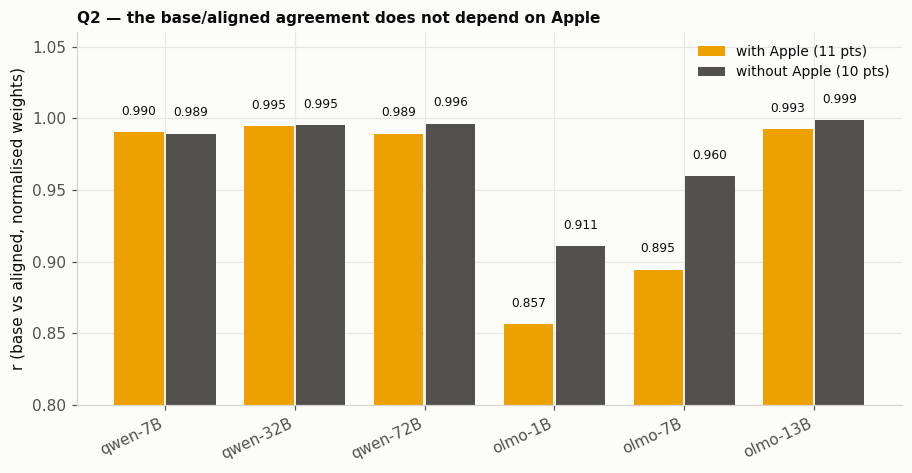

   model  fam  r_incl  r_excl  change
 qwen-7B qwen  0.9903  0.9893 -0.0009
qwen-32B qwen  0.9946  0.9952  0.0005
qwen-72B qwen  0.9893  0.9962  0.0069
 olmo-1B olmo  0.8566  0.9110  0.0544
 olmo-7B olmo  0.8945  0.9596  0.0651
olmo-13B olmo  0.9926  0.9988  0.0062

r is unchanged or HIGHER without Apple in 6 of 6 pairs (mean change +0.022).
Apple is the noisiest brand, so removing it slightly cleans the correlation up.


In [4]:
rows = []
for pf, af, s in PAIRS:
    kb, ka = (pf, s, "none"), (af, s, "none")
    if kb not in RUNS or ka not in RUNS:
        continue
    rec = dict(model=f"{af}-{s}B", fam=af)
    for tag, f, lv in [("incl", lambda x: x, LEVELS), ("excl", drop_apple, LEVELS4)]:
        fb = FeatureBT(r2_warn=None).fit(f(RUNS[kb]))
        fa = FeatureBT(r2_warn=None).fit(f(RUNS[ka]))
        xb = [fb.normalised(k, l) for k, ls in lv.items() for l in ls]
        xa = [fa.normalised(k, l) for k, ls in lv.items() for l in ls]
        rec[f"r_{tag}"] = st.pearsonr(xb, xa)[0]
    rows.append(rec)
RR = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8.4, 4.4))
x = np.arange(len(RR))
ax.bar(x - .2, RR.r_incl, .38, color=INCL_C, label="with Apple (11 pts)", zorder=2)
ax.bar(x + .2, RR.r_excl, .38, color=EXCL_C, label="without Apple (10 pts)", zorder=2)
for xi, (a, b) in enumerate(zip(RR.r_incl, RR.r_excl)):
    ax.text(xi - .2, a + .012, f"{a:.3f}", ha="center", fontsize=8)
    ax.text(xi + .2, b + .012, f"{b:.3f}", ha="center", fontsize=8)
ax.set_xticks(x, RR.model, rotation=25, ha="right")
ax.set_ylim(.8, 1.06)
ax.set_ylabel("r (base vs aligned, normalised weights)")
ax.set_title("Q2 — the base/aligned agreement does not depend on Apple",
             loc="left", fontweight="bold", fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
save(fig, "na2_base_vs_aligned")
plt.show()

RR["change"] = RR.r_excl - RR.r_incl
print(RR.round(4).to_string(index=False))
print("\nr is unchanged or HIGHER without Apple in "
      f"{int((RR.change >= -0.002).sum())} of {len(RR)} pairs "
      f"(mean change {RR.change.mean():+.3f}).")
print("Apple is the noisiest brand, so removing it slightly cleans the correlation up.")

---
# Q3 — does the brand decay survive without Apple?

The real question. For each aligned model, every brand's normalised weight across the four
contracts, and its **swing** (max − min).

**Watch for one trap.** Weights are centred within a feature, so in the 5-brand fit *Apple moving
pulls the other four the opposite way whether or not they moved on their own*. Re-fitting on
4 brands removes that leakage, so the comparison below is "how much did the other four really
move" versus "how much did they appear to move while Apple was in the fit".

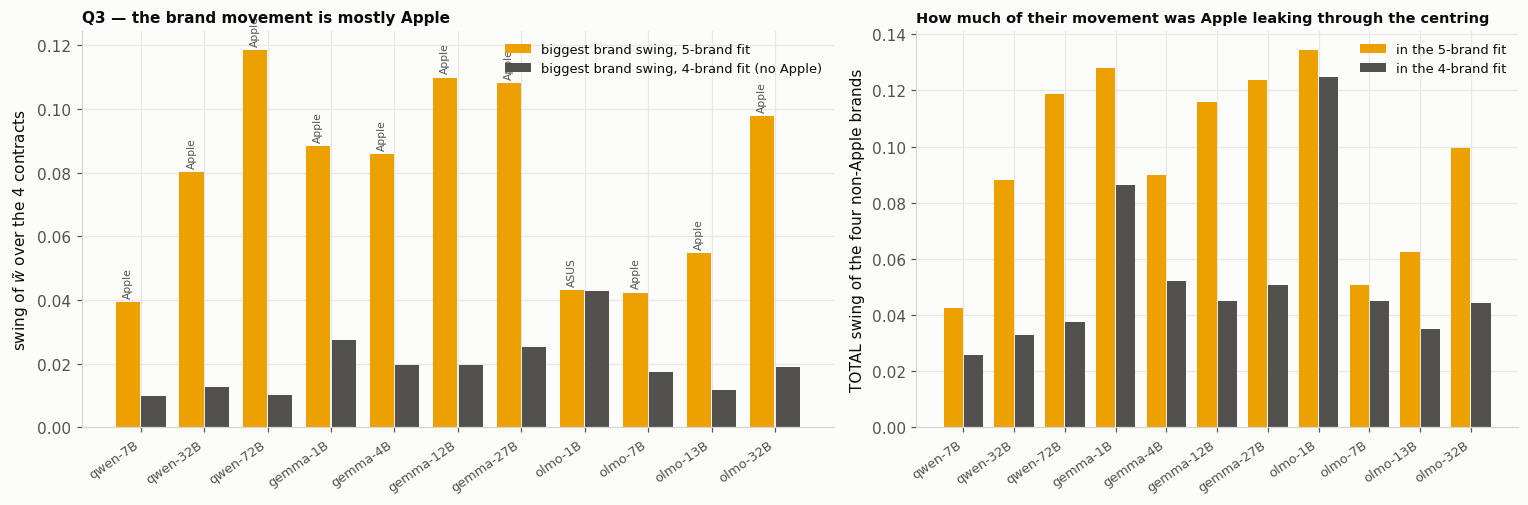

    model   fam top_incl  top_incl_v top_excl  top_excl_v  apple  other4_in5fit  other4_in4fit
  qwen-7B  qwen    Apple      0.0392   Lenovo      0.0099 0.0392         0.0423         0.0258
 qwen-32B  qwen    Apple      0.0800       HP      0.0128 0.0800         0.0882         0.0328
 qwen-72B  qwen    Apple      0.1185   Lenovo      0.0103 0.1185         0.1186         0.0377
 gemma-1B gemma    Apple      0.0883       HP      0.0273 0.0883         0.1280         0.0863
 gemma-4B gemma    Apple      0.0858       HP      0.0194 0.0858         0.0898         0.0520
gemma-12B gemma    Apple      0.1097       HP      0.0196 0.1097         0.1159         0.0448
gemma-27B gemma    Apple      0.1081       HP      0.0253 0.1081         0.1237         0.0507
  olmo-1B  olmo     ASUS      0.0431     ASUS      0.0429 0.0338         0.1344         0.1249
  olmo-7B  olmo    Apple      0.0423       HP      0.0172 0.0423         0.0507         0.0449
 olmo-13B  olmo    Apple      0.0548       HP     

In [5]:
rows, traj = [], {}
for fam, s in ALIGNED:
    cs = [c for c in CON if (fam, s, c) in RUNS]
    if len(cs) < 4:
        continue
    Wi = {c: FeatureBT(r2_warn=None).fit(RUNS[(fam, s, c)]) for c in cs}
    We = {c: FeatureBT(r2_warn=None).fit(drop_apple(RUNS[(fam, s, c)])) for c in cs}
    swi = {b: np.ptp([Wi[c].normalised("brand", b) for c in cs]) for b in BRANDS}
    swe = {b: np.ptp([We[c].normalised("brand", b) for c in cs]) for b in OTHER4}
    traj[(fam, s)] = (cs, We)
    rows.append(dict(model=f"{fam}-{s}B", fam=fam,
                     top_incl=max(swi, key=swi.get), top_incl_v=max(swi.values()),
                     top_excl=max(swe, key=swe.get), top_excl_v=max(swe.values()),
                     apple=swi["Apple"],
                     other4_in5fit=sum(swi[b] for b in OTHER4),
                     other4_in4fit=sum(swe.values())))
SW = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.7), gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
x = np.arange(len(SW))
ax.bar(x - .2, SW.top_incl_v, .38, color=INCL_C, zorder=2,
       label="biggest brand swing, 5-brand fit")
ax.bar(x + .2, SW.top_excl_v, .38, color=EXCL_C, zorder=2,
       label="biggest brand swing, 4-brand fit (no Apple)")
for xi, (a, nm) in enumerate(zip(SW.top_incl_v, SW.top_incl)):
    ax.text(xi - .2, a + .002, nm, ha="center", fontsize=7, rotation=90, color=INK_MUTED)
ax.set_xticks(x, SW.model, rotation=35, ha="right", fontsize=8.5)
ax.set_ylabel(r"swing of $\tilde{w}$ over the 4 contracts")
ax.set_title("Q3 — the brand movement is mostly Apple", loc="left", fontweight="bold",
             fontsize=10)
ax.legend(frameon=False, fontsize=8.5)

ax = axes[1]
ax.bar(x - .2, SW.other4_in5fit, .38, color=INCL_C, zorder=2,
       label="in the 5-brand fit")
ax.bar(x + .2, SW.other4_in4fit, .38, color=EXCL_C, zorder=2,
       label="in the 4-brand fit")
ax.set_xticks(x, SW.model, rotation=35, ha="right", fontsize=8.5)
ax.set_ylabel("TOTAL swing of the four non-Apple brands")
ax.set_title("How much of their movement was Apple leaking through the centring",
             loc="left", fontweight="bold", fontsize=9.5)
ax.legend(frameon=False, fontsize=8.5)
fig.tight_layout()
save(fig, "na3_brand_swing")
plt.show()

print(SW.round(4).to_string(index=False))
print(f"\nbiggest swing: {SW.top_incl_v.mean():.4f} with Apple -> {SW.top_excl_v.mean():.4f} "
      f"without  (x{SW.top_excl_v.mean() / SW.top_incl_v.mean():.2f})")
print(f"the four non-Apple brands move {SW.other4_in5fit.mean():.4f} in the 5-brand fit but only "
      f"{SW.other4_in4fit.mean():.4f} on their own "
      f"-> about {100 * (1 - SW.other4_in4fit.mean() / SW.other4_in5fit.mean()):.0f}% of their "
      "apparent movement was Apple's, via the centring.")
print(f"\nApple is the biggest mover in {int((SW.top_incl == 'Apple').sum())}/{len(SW)} models "
      "when it is in the fit.")

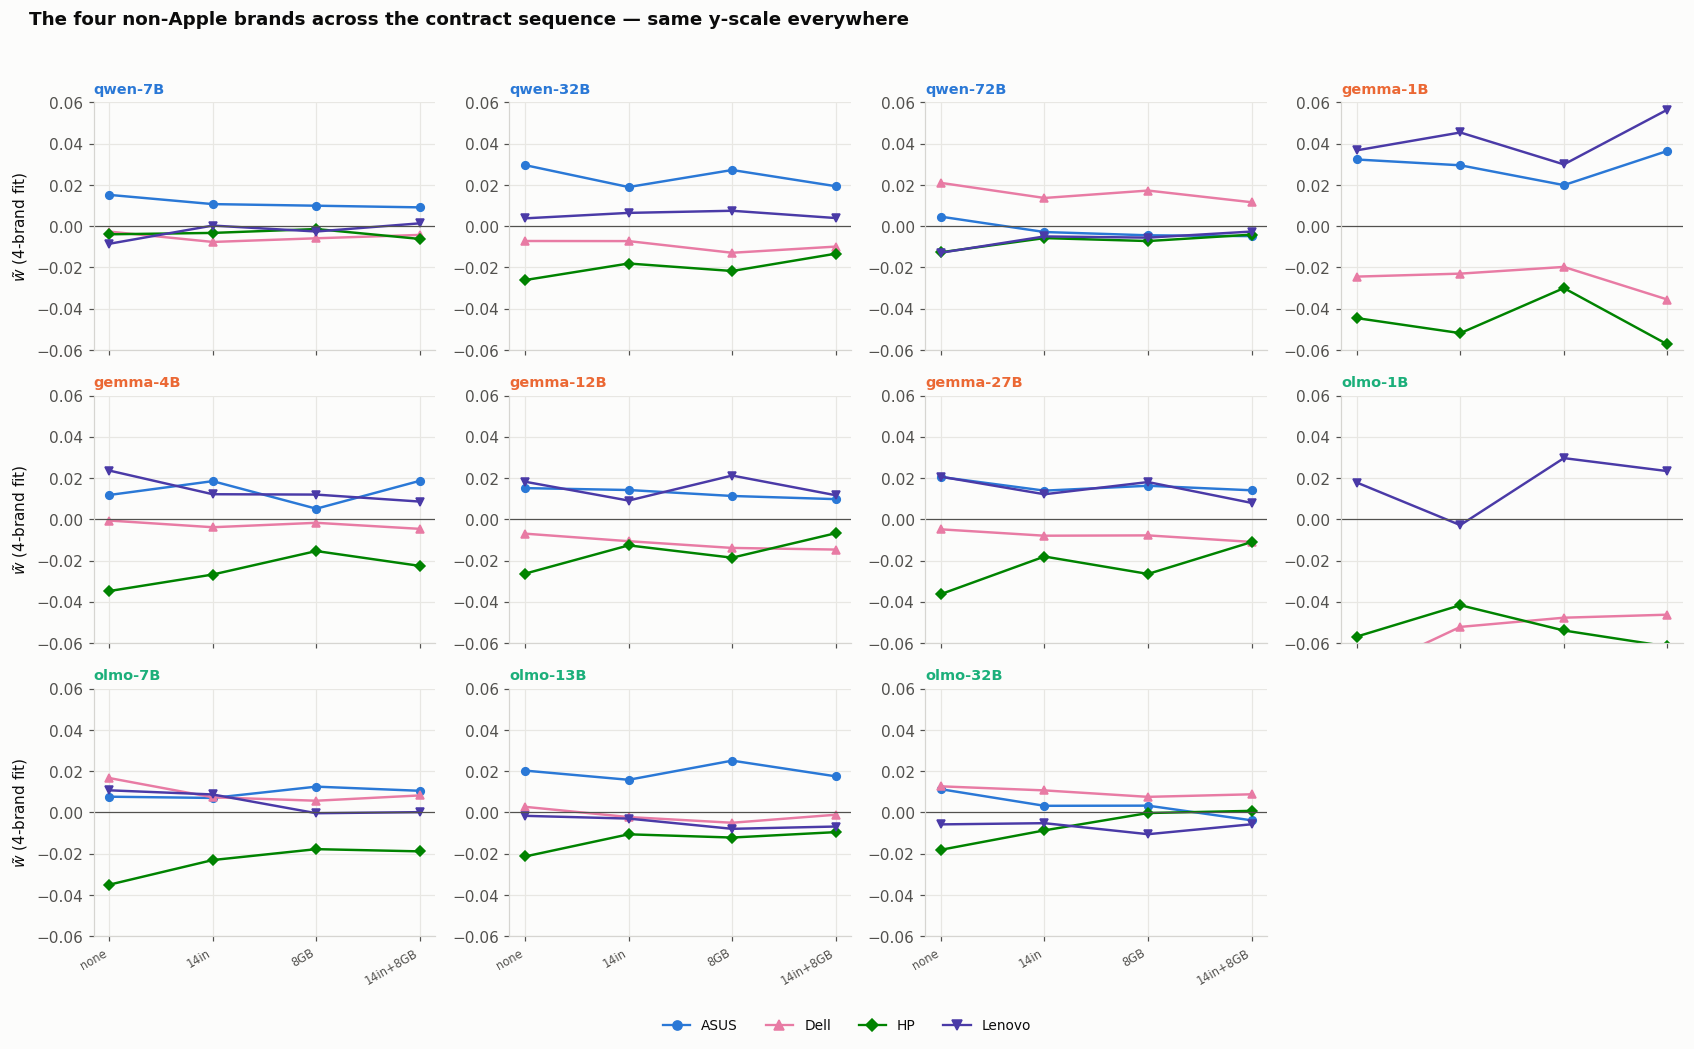

brand ORDER of the four, first contract -> last (4-brand fit):
   qwen-7B: 4 distinct order(s)   ASUS > Dell > HP > Lenovo  ->  ASUS > Lenovo > Dell > HP
   qwen-32B: 1 distinct order(s)   ASUS > Lenovo > Dell > HP  ->  ASUS > Lenovo > Dell > HP
   qwen-72B: 3 distinct order(s)   Dell > ASUS > HP > Lenovo  ->  Dell > Lenovo > HP > ASUS
   gemma-1B: 1 distinct order(s)   Lenovo > ASUS > Dell > HP  ->  Lenovo > ASUS > Dell > HP
   gemma-4B: 2 distinct order(s)   Lenovo > ASUS > Dell > HP  ->  ASUS > Lenovo > Dell > HP
   gemma-12B: 3 distinct order(s)   Lenovo > ASUS > Dell > HP  ->  Lenovo > ASUS > HP > Dell
   gemma-27B: 2 distinct order(s)   Lenovo > ASUS > Dell > HP  ->  ASUS > Lenovo > Dell > HP
   olmo-1B: 2 distinct order(s)   ASUS > Lenovo > HP > Dell  ->  ASUS > Lenovo > Dell > HP
   olmo-7B: 3 distinct order(s)   Dell > Lenovo > ASUS > HP  ->  ASUS > Dell > Lenovo > HP
   olmo-13B: 1 distinct order(s)   ASUS > Dell > Lenovo > HP  ->  ASUS > Dell > Lenovo > HP
   olmo-32B: 3 dis

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(15.5, 9.5), sharex=True)
for ax, (fam, s) in zip(axes.ravel(), ALIGNED):
    if (fam, s) not in traj:
        ax.axis("off"); continue
    cs, We = traj[(fam, s)]
    xs = [CON.index(c) for c in cs]
    for b in OTHER4:
        ax.plot(xs, [We[c].normalised("brand", b) for c in cs], "-",
                marker=BRAND_MARKER[b], color=BRAND_COLOR[b], ms=5, lw=1.6)
    ax.axhline(0, color=INK_MUTED, lw=.8)
    ax.set_ylim(-.06, .06)
    ax.set_xticks(range(4), cols, rotation=30, ha="right", fontsize=7.5)
    ax.set_title(f"{fam}-{s}B", loc="left", fontweight="bold", fontsize=9.5,
                 color=FAM_COLOR[fam])
for a in axes[-1]:
    if not a.has_data(): a.axis("off")
axes[0, 0].set_ylabel(r"$\tilde{w}$ (4-brand fit)")
axes[1, 0].set_ylabel(r"$\tilde{w}$ (4-brand fit)")
axes[2, 0].set_ylabel(r"$\tilde{w}$ (4-brand fit)")
fig.legend(handles=[Line2D([], [], marker=BRAND_MARKER[b], color=BRAND_COLOR[b], label=b)
                    for b in OTHER4], ncol=4, loc="lower center", frameon=False,
           bbox_to_anchor=(.5, -.01), fontsize=9)
fig.suptitle("The four non-Apple brands across the contract sequence — same y-scale everywhere",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout(rect=[0, .03, 1, .96])
save(fig, "na4_other_brands")
plt.show()

print("brand ORDER of the four, first contract -> last (4-brand fit):")
for (fam, s), (cs, We) in traj.items():
    orders = [tuple(sorted(OTHER4, key=lambda b: -We[c].weights_["brand"][b])) for c in cs]
    print(f"   {fam}-{s}B: {len(set(orders))} distinct order(s)   "
          f"{' > '.join(orders[0])}  ->  {' > '.join(orders[-1])}")

---
## What survives

| | with Apple | without Apple |
|---|---|---|
| **adherence** (κ, ram) | — | **unchanged**, largest shift 0.03 |
| **base vs aligned** r | 0.857 – 0.995 | **same or better**, 0.911 – 0.999 |
| **biggest brand swing** | 0.079 | **0.020** — four times smaller |

**Q1 and Q2 are clean controls and they pass.** Neither adherence nor the base-vs-aligned
agreement depends on Apple. Removing it even *improves* the correlation slightly, because Apple
is the noisiest brand — so "the preferences are pretrained" is not an Apple artefact.

**Q3 is the real result: the brand effect is mostly Apple.** With Apple in the fit, the biggest
brand swing averages 0.079; drop it and the largest remaining brand moves 0.020. And about
**45% of what the other four appeared to do was Apple's movement leaking through the
zero-mean centring** — their total swing falls from 0.096 in the 5-brand fit to 0.053 when fitted
on their own.

**But it is not zero.** The remaining four brands still reorder in most models, by a small amount,
and with no consistent direction across families. So the honest statement is:

> A contract reorders the brands almost entirely by pushing **Apple** down. There is a small
> residual movement among the other brands, too small and too inconsistent to interpret with the
> data we have.

This confirms the old `brand_consistency.ipynb` result ("drop Apple and the other four are
stable") on all three families, and quantifies how much of the leftover motion was an artefact of
having Apple in the fit at all.